# Mineração de Dados — PL6 (Text Mining & NLP III)

#### Nome: Fernando Jorge Silva Pires

#### Numero: PG60253


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import gensim
import gensim.downloader as api

import warnings
warnings.filterwarnings('ignore')

print("Setup completo!")

Setup completo!


## Parte 1 — Word Embeddings (Gensim)

In [20]:
# Questão 1.1. Carregar os modelos
print("Modelos disponíveis no Gensim:")
for model_name in list(api.info()['models'].keys())[:5]:
    print(f" - {model_name}")

print("\n" + "="*60)
print("CARREGANDO MODELOS (pode levar alguns minutos)...")
print("="*60)

# Word2Vec Google News
word2vec = api.load("word2vec-google-news-300")
print("\n1. Word2Vec carregado!")

# GloVe Twitter
glove = api.load("glove-twitter-200")
print("2. GloVe carregado!")

# FastText Wikipedia
fasttext = api.load("fasttext-wiki-news-subwords-300")
print("3. FastText carregado!")

print("Todos os modelos carregados com sucesso!")

Modelos disponíveis no Gensim:
 - fasttext-wiki-news-subwords-300
 - conceptnet-numberbatch-17-06-300
 - word2vec-ruscorpora-300
 - word2vec-google-news-300
 - glove-wiki-gigaword-50

CARREGANDO MODELOS (pode levar alguns minutos)...

1. Word2Vec carregado!
[==================================================] 100.0% 758.5/758.5MB downloaded
2. GloVe carregado!
[==================================================] 100.0% 958.5/958.4MB downloaded
3. FastText carregado!
Todos os modelos carregados com sucesso!


In [21]:
# Questão 1.2 — Similaridade de Palavras
word_pairs = [
 ("carro", "automóvel"),
 ("feliz", "contente"),
 ("gato", "cão"),
 ("rei", "rainha"),
 ("computador", "teclado"),
 ("amor", "ódio"),
 ("rápido", "veloz"),
 ("bom", "mau")
]

results = {
 'word1': [],
 'word2': [],
 'similarity_word2vec': [],
 'similarity_glove': [],
 'similarity_fasttext': []
}

In [22]:
# Função de similaridade
def get_similarity(model, word1, word2, model_name):
    try:
        similarity = model.similarity(word1, word2)
        return similarity
    except KeyError as e:
        print(f"⚠ {model_name}: palavra '{e}' não encontrada")
        return np.nan

In [23]:
# Calcular similaridades
for w1, w2 in word_pairs:

    results['word1'].append(w1)
    results['word2'].append(w2)

    sim_w2v = get_similarity(word2vec, w1, w2, "Word2Vec")
    results['similarity_word2vec'].append(sim_w2v)

    sim_glove = get_similarity(glove, w1, w2, "GloVe")
    results['similarity_glove'].append(sim_glove)

    sim_ft = get_similarity(fasttext, w1, w2, "FastText")
    results['similarity_fasttext'].append(sim_ft)

df_similarities = pd.DataFrame(results)

print("="*60)
print("SIMILARIDADES ENTRE PARES DE PALAVRAS")
print("="*60)

print(df_similarities)

⚠ Word2Vec: palavra '"Key 'automóvel' not present"' não encontrada
⚠ FastText: palavra '"Key 'automóvel' not present"' não encontrada
⚠ Word2Vec: palavra '"Key 'contente' not present"' não encontrada
⚠ Word2Vec: palavra '"Key 'cão' not present"' não encontrada
⚠ FastText: palavra '"Key 'cão' not present"' não encontrada
⚠ Word2Vec: palavra '"Key 'rainha' not present"' não encontrada
⚠ FastText: palavra '"Key 'rainha' not present"' não encontrada
⚠ Word2Vec: palavra '"Key 'computador' not present"' não encontrada
⚠ Word2Vec: palavra '"Key 'ódio' not present"' não encontrada
⚠ FastText: palavra '"Key 'ódio' not present"' não encontrada
⚠ Word2Vec: palavra '"Key 'veloz' not present"' não encontrada
SIMILARIDADES ENTRE PARES DE PALAVRAS
        word1      word2  similarity_word2vec  similarity_glove  \
0       carro  automóvel                  NaN          0.236243   
1       feliz   contente                  NaN          0.418507   
2        gato        cão                  NaN          0

#### Questão 1.2.5

D) rápido-veloz

#### Questão 1.2.6

B) Porque palavras opostas aparecem em contextos semelhantes

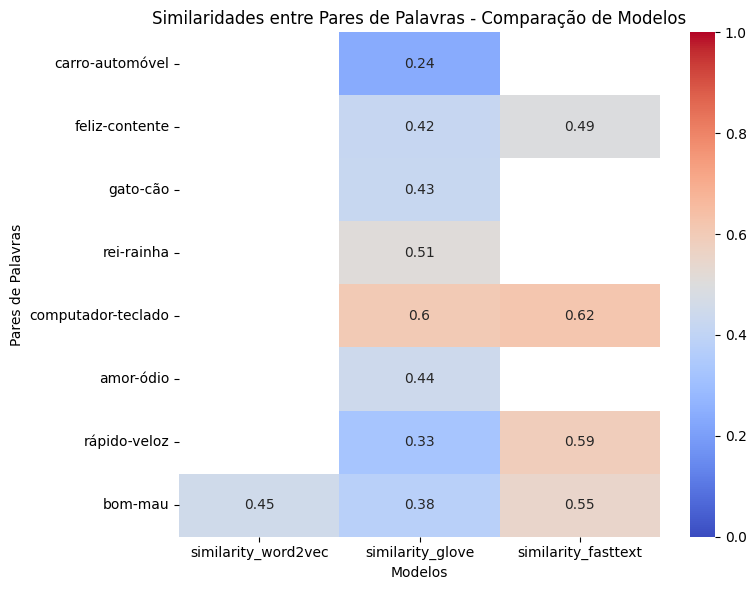

In [24]:
# Questão 1.3 — Heatmap
plt.figure(figsize=(8,6))

similarity_matrix = df_similarities[
    ['similarity_word2vec','similarity_glove','similarity_fasttext']
]

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    yticklabels=df_similarities['word1'] + "-" + df_similarities['word2']
)

plt.title('Similaridades entre Pares de Palavras - Comparação de Modelos')
plt.ylabel('Pares de Palavras')
plt.xlabel('Modelos')

plt.tight_layout()
plt.show()

In [25]:
# Questão 1.4 — Analogias
analogies = [
 ('rei', 'homem', 'mulher'),
 ('paris', 'frança', 'alemanha'),
 ('correr', 'correu', 'comeu')
]

print("="*60)
print("TESTAR ANALOGIAS")
print("="*60)

TESTAR ANALOGIAS


In [26]:
for model_name, model in [
    ('Word2Vec', word2vec),
    ('GloVe', glove),
    ('FastText', fasttext)
]:

    print(f"\n📊 {model_name}")
    print("-"*40)

    for king, man, woman in analogies:

        positive = [woman, king]
        negative = [man]

        try:
            result = model.most_similar(
                positive=positive,
                negative=negative,
                topn=3
            )

            print(f"\n {king} - {man} + {woman} ?")

            for word, score in result:
                print(f" → {word}: {score:.4f}")

        except KeyError as e:
            print("Palavra não encontrada:", e)


📊 Word2Vec
----------------------------------------
Palavra não encontrada: "Key 'mulher' not present in vocabulary"
Palavra não encontrada: "Key 'alemanha' not present in vocabulary"
Palavra não encontrada: "Key 'comeu' not present in vocabulary"

📊 GloVe
----------------------------------------

 rei - homem + mulher ?
 → rainha: 0.5743
 → vivi: 0.4985
 → tia: 0.4846

 paris - frança + alemanha ?
 → london: 0.5894
 → berlin: 0.5779
 → france: 0.5676

 correr - correu + comeu ?
 → comer: 0.6305
 → hora: 0.5255
 → tomar: 0.5175

📊 FastText
----------------------------------------

 rei - homem + mulher ?
 → ente: 0.5816
 → repente: 0.5687
 → achei: 0.5643
Palavra não encontrada: "Key 'alemanha' not present in vocabulary"
Palavra não encontrada: "Key 'comeu' not present in vocabulary"


#### Questão 1.4

B) Glove

In [27]:
# Questão 1.5 — Palavras OOV
test_words = [
 "neural",
 "transformers",
 "chatgpt",
 "pós-modernismo"
]

print("="*60)
print("TESTANDO PALAVRAS FORA DO VOCABULÁRIO")
print("="*60)

TESTANDO PALAVRAS FORA DO VOCABULÁRIO


In [28]:
for word in test_words:

    print(f"\nPalavra: '{word}'")

    for model_name, model in [
        ('Word2Vec', word2vec),
        ('GloVe', glove),
        ('FastText', fasttext)
    ]:

        try:
            vector = model[word]

            print(f"✓ {model_name}: encontrada (vetor dimensão {len(vector)})")

            similar = model.most_similar(word, topn=3)

            print("Palavras similares:", [s[0] for s in similar])

        except KeyError:
            print(f"✗ {model_name}: NÃO encontrada")

            if model_name == 'FastText' and hasattr(model, "word_vec"):
                try:
                    vector = model.word_vec(word, use_norm=True)
                    print("✓ FastText (subwords) conseguiu gerar vetor!")
                except:
                    pass


Palavra: 'neural'
✓ Word2Vec: encontrada (vetor dimensão 300)
Palavras similares: ['neuronal', 'neurons', 'neural_circuits']
✓ GloVe: encontrada (vetor dimensão 200)
Palavras similares: ['pathways', 'adaptive', 'mechanisms']
✓ FastText: encontrada (vetor dimensão 300)
Palavras similares: ['neuronal', 'non-neural', 'cortical']

Palavra: 'transformers'
✓ Word2Vec: encontrada (vetor dimensão 300)
Palavras similares: ['transformer', 'substations', '##KV']
✓ GloVe: encontrada (vetor dimensão 200)
Palavras similares: ['transformer', 'avengers', 'terminator']
✓ FastText: encontrada (vetor dimensão 300)
Palavras similares: ['transformer', 'inverters', 'autotransformers']

Palavra: 'chatgpt'
✗ Word2Vec: NÃO encontrada
✗ GloVe: NÃO encontrada
✗ FastText: NÃO encontrada

Palavra: 'pós-modernismo'
✗ Word2Vec: NÃO encontrada
✗ GloVe: NÃO encontrada
✗ FastText: NÃO encontrada


#### Questão 1.5.2

 D) Nenhum conseguiu

#### Questão 1.5.3

B) Porque usa subpalavras (n-grams de caracteres)

## Parte 2 — BERT

In [7]:
# Questão 2.1 — Carregar BERT
from transformers import AutoTokenizer, AutoModel
import torch

print("="*60)
print("CARREGANDO BERT...")
print("="*60)

model_name = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

print(f"Modelo '{model_name}' carregado!")
print("Vocabulário:", tokenizer.vocab_size)
print("Dimensão embeddings:", model.config.hidden_size)

CARREGANDO BERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4668.21it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo 'bert-base-multilingual-cased' carregado!
Vocabulário: 119547
Dimensão embeddings: 768


In [16]:
# Questão 2.2 — Palavra Polissémica
sentences = [ 
    "Fui ao banco depositar dinheiro.",           # banco financeiro 
    "Sentei no banco da praça para descansar.",   # banco (assento) 
    "O banco de dados está corrompido.",          # banco de dados
    "O barco encalhou no banco de areia.",        # banco de areia
] 

In [17]:
print("\n" + "="*60) 
print("ANÁLISE DA PALAVRA 'BANCO' EM DIFERENTES CONTEXTOS") 
print("="*60) 

def get_word_embedding(sentence, word, tokenizer, model):
    inputs = tokenizer(sentence, return_tensors="pt") 
    with torch.no_grad():
        outputs = model(**inputs) 
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    word_positions = [] 
    for i, token in enumerate(tokens):
        if word in token or (token.startswith("##") and word in token): 
            word_positions.append(i)

    word_embedding = outputs.last_hidden_state[0, word_positions[0]].numpy()
    return word_embedding, tokens 


banco_embeddings = []

# Loop de extração
for i, sentence in enumerate(sentences):
    print(f"\n Frase {i+1}: {sentence}") 

    embedding, tokens = get_word_embedding(sentence, "banco", tokenizer, model) 
    if embedding is not None: 
        banco_embeddings.append(embedding) 
        print(f"  Tokens: {tokens}") 
        print(f"  Embedding shape: {embedding.shape}") 
        print(f"  Primeiros 10 valores: {embedding[:10].round(3)}")


ANÁLISE DA PALAVRA 'BANCO' EM DIFERENTES CONTEXTOS

 Frase 1: Fui ao banco depositar dinheiro.
  Tokens: ['[CLS]', 'Fu', '##i', 'ao', 'banco', 'de', '##posit', '##ar', 'dinheiro', '.', '[SEP]']
  Embedding shape: (768,)
  Primeiros 10 valores: [ 0.309 -0.594  0.681  0.691 -0.144  0.621 -0.102  0.138 -0.025  0.066]

 Frase 2: Sentei no banco da praça para descansar.
  Tokens: ['[CLS]', 'Sent', '##ei', 'no', 'banco', 'da', 'pra', '##ça', 'para', 'des', '##cans', '##ar', '.', '[SEP]']
  Embedding shape: (768,)
  Primeiros 10 valores: [ 0.026 -0.266  0.353  0.313  0.215  0.762 -0.526  0.032 -0.276  0.013]

 Frase 3: O banco de dados está corrompido.
  Tokens: ['[CLS]', 'O', 'banco', 'de', 'dados', 'está', 'cor', '##rom', '##pido', '.', '[SEP]']
  Embedding shape: (768,)
  Primeiros 10 valores: [ 0.369 -0.77   0.118  0.827 -0.05   0.941 -0.122 -0.304 -0.366 -0.833]

 Frase 4: O barco encalhou no banco de areia.
  Tokens: ['[CLS]', 'O', 'barco', 'en', '##cal', '##hou', 'no', 'banco', 'de', 

#### Questão 2.2.2
A) 1 token


MATRIZ DE SIMILARIDADE - EMBEDDINGS DE 'BANCO'


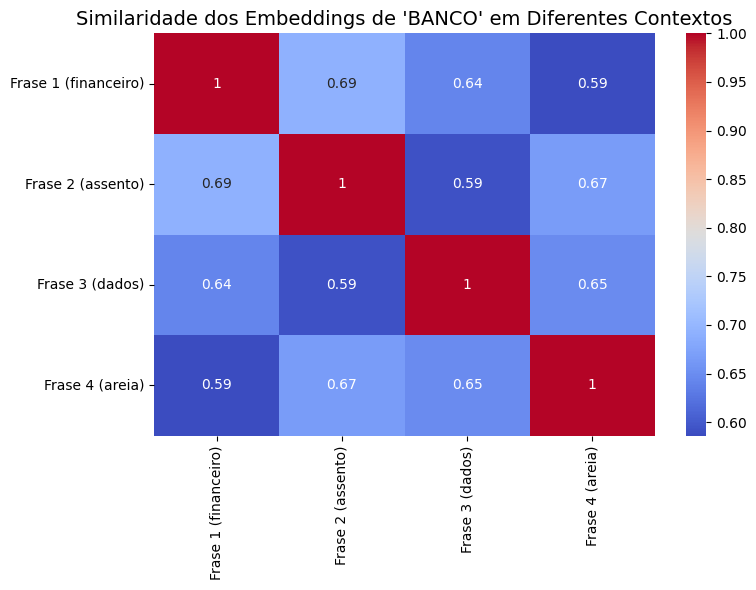


📊 Análise das similaridades:
  Frase 1 (financeiro) ↔ Frase 2 (assento): 0.6915
  Frase 1 (financeiro) ↔ Frase 3 (dados): 0.6423
  Frase 1 (financeiro) ↔ Frase 4 (areia): 0.5860
  Frase 2 (assento) ↔ Frase 3 (dados): 0.5915
  Frase 2 (assento) ↔ Frase 4 (areia): 0.6654
  Frase 3 (dados) ↔ Frase 4 (areia): 0.6482


In [18]:
# Questão 2.3 — Similaridade
if len(banco_embeddings) >= 4:
    print("\n" + "="*60)
    print("MATRIZ DE SIMILARIDADE - EMBEDDINGS DE 'BANCO'")
    print("="*60)

    # Calcular matriz de similaridade
    similarity_matrix = np.zeros((4, 4))
    for i in range(4):
        for j in range(4):
            similarity_matrix[i, j] = cosine_similarity([banco_embeddings[i]], [banco_embeddings[j]])[0][0]

    # Criar labels para as frases
    labels = [
        "Frase 1 (financeiro)",
        "Frase 2 (assento)",
        "Frase 3 (dados)",
        "Frase 4 (areia)"
    ]

    # DataFrame para visualização
    df_sim = pd.DataFrame(similarity_matrix, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))

    sns.heatmap(df_sim, annot=True, cmap='coolwarm')
    
    plt.title("Similaridade dos Embeddings de 'BANCO' em Diferentes Contextos", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n📊 Análise das similaridades:")
    for i in range(4):
        for j in range(i+1, 4):
            print(f"  {labels[i]} ↔ {labels[j]}: {similarity_matrix[i,j]:.4f}")

#### Questão 2.3.2

A) Frase 1 (financeiro) e Frase 2 (assento)

#### Questão 2.3.3

C) Frase 1 (financeiro) e Frase 4 (areia)

#### Questão 2.3.4

B) São contextuais, variando conforme o significado